# Customer Behavior EDA

Objective: Analyze customer ordering cadence, reorder intensity, and basket behavior.

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Soda,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Organic Unsweetened Vanilla Almond Milk,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Original Beef Jerky,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,Aged White Cheddar Popcorn,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0000,0.0000,2015-07-01,XL Pick-A-Size Paper Towel Rolls,1,0


# Customer Behavior EDA

**Data Mode Configuration**:
- Set `USE_SAMPLE = False` in cell 1 for full dataset analysis (production)
- Set `USE_SAMPLE = True` in cell 1 for quick sample testing (development)

Objective: Analyze customer ordering cadence, reorder intensity, and basket behavior.

In [2]:
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)
customer_kpi = customer_kpi.drop(columns=["user_id"])
display(customer_kpi.describe(include="all"))

summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        avg_days_since_prior_order=("days_since_prior_order", "mean"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)
summary_by_reordered

,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
count,"206,209.0000","206,209.0000","206,209.0000","206,209.0000","206,209.0000"
mean,15.5904,157.2894,0.4322,13.0137,92.7532
std,16.6548,204.2082,0.2121,5.6614,158.4004
min,3.0000,3.0000,0.0000,0.0000,0.0000
25%,5.0000,39.0000,0.2679,8.4757,10.0000
50%,9.0000,83.0000,0.4286,12.6721,33.0000
75%,19.0000,188.0000,0.5957,17.1867,101.0000
max,99.0000,"3,725.0000",0.9895,29.7030,"3,275.0000"


,avg_days_since_prior_order,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,10.6542,6.0000,16.0000,13307953
1,10.2107,16.0000,102.0000,19126536


## Bivariate Comparison

This section was moved from the overview notebook and consolidated here for customer behavior interpretation.

## - Reorder Behavior

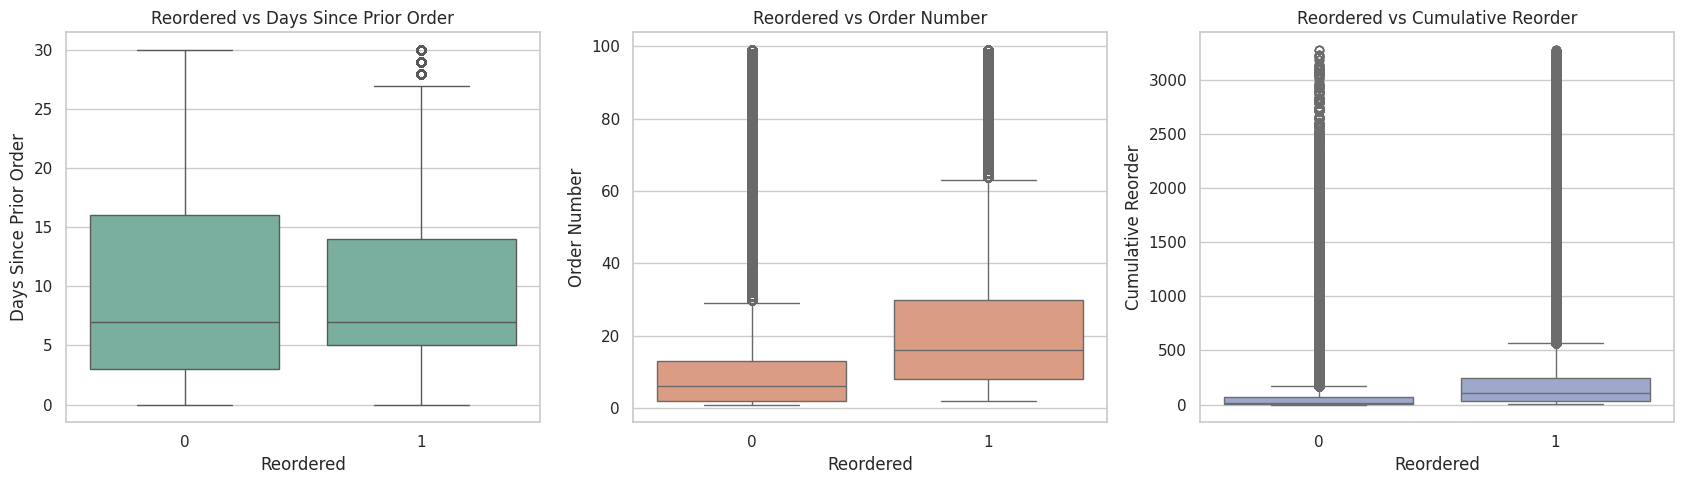

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [4]:
# Compare metrics between reordered and non-reordered items
reordered_yes = df[df["reordered"] == 1]
reordered_no = df[df["reordered"] == 0]

comparison_stats = {
    "days_since_prior_order": reordered_yes["days_since_prior_order"].mean() - reordered_no["days_since_prior_order"].mean(),
    "order_number": reordered_yes["order_number"].median() - reordered_no["order_number"].median(),
    "cumulative_reorder": reordered_yes["cumulative_reorder_per_customer"].median() - reordered_no["cumulative_reorder_per_customer"].median(),
}

pd.Series(comparison_stats, name="difference").to_frame()

,difference
days_since_prior_order,-0.4435
order_number,10.0000
cumulative_reorder,86.0000


## Key Insight Notes
- If days_since_prior_order difference is negative, reordered users tend to come back sooner.
- Positive median order_number difference indicates reorders increase with customer order history.
- Positive cumulative_reorder median difference indicates reorder behavior is reinforced over time.

## - Order & Reorder Behavior / Day time 

In [5]:
order_level = (
    df.groupby("order_id")
    .agg(
        order_date=("order_date", "first"),
        order_dow=("order_dow", "first"),
        order_hour_of_day=("order_hour_of_day", "first"),
        total_products=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        days_since_prior_order=("days_since_prior_order", "first"),
    )
    .reset_index()
)

order_level["order_date"] = pd.to_datetime(order_level["order_date"])
order_level["month_num"] = order_level["order_date"].dt.month
order_level["month_name"] = order_level["order_date"].dt.month_name().str[:3]
order_level["week_of_year"] = order_level["order_date"].dt.isocalendar().week.astype(int)

# Explicit weekday labels for readability in tables/plots.
day_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
order_level["day_name"] = pd.Categorical(
    order_level["order_dow"].map(day_map),
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
)

print("Order-Level Summary (numeric):")
display(
    order_level[[
        "order_hour_of_day",
        "total_products",
        "reorder_rate",
        "days_since_prior_order",
        "month_num",
        "week_of_year",
    ]].describe()
)

print("Order-Level Summary (categorical):")
display(order_level[["day_name", "month_name"]].describe(include="all"))

print("Order-Level Summary (date):")
display(
    pd.DataFrame(
        {
            "count": [order_level["order_date"].notna().sum()],
            "min": [order_level["order_date"].min()],
            "max": [order_level["order_date"].max()],
            "nunique": [order_level["order_date"].nunique()],
        },
        index=["order_date"],
    )
)

print("Quality checks:")
print(f"Unique orders: {order_level['order_id'].nunique():,}")
print(f"Date range: {order_level['order_date'].min().date()} to {order_level['order_date'].max().date()}")
print(f"Unique months: {order_level['month_name'].nunique()}")

Order-Level Summary (numeric):


,order_hour_of_day,total_products,reorder_rate,days_since_prior_order,month_num,week_of_year
count,"3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000"
mean,13.4435,10.0889,0.5987,10.0205,5.7425,23.0116
std,4.2262,7.5254,0.3380,9.0508,3.1851,13.7276
min,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000
25%,10.0000,5.0000,0.3333,3.0000,3.0000,13.0000
50%,13.0000,8.0000,0.6667,7.0000,5.0000,21.0000
75%,16.0000,14.0000,0.9091,14.0000,7.0000,29.0000
max,23.0000,145.0000,1.0000,30.0000,12.0000,52.0000


Order-Level Summary (categorical):


,day_name,month_name
count,3214874,3214874
unique,7,12
top,Sun,Jun
freq,557772,465312


Order-Level Summary (date):


,count,min,max,nunique
order_date,3214874,2014-07-01,2015-07-01,366


Quality checks:
Unique orders: 3,214,874
Date range: 2014-07-01 to 2015-07-01
Unique months: 12


In [6]:
day_map = {
    0: "Sun", 1: "Mon", 2: "Tue",
    3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"
}

order_level["day_name"] = order_level["order_dow"].map(day_map)
order_level["day_name"] = pd.Categorical(
    order_level["day_name"],
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
    )

# Build full 7x24 grid to make gaps explicit (instead of silently missing slots).
all_day_hour = pd.MultiIndex.from_product(
    [["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], range(24)],
    names=["day_name", "order_hour_of_day"],
)

customer_kpi = (
    order_level.groupby(["day_name", "order_hour_of_day"], observed=False)
    .agg(
        order_count=("order_id", "nunique"),
        avg_products_per_order=("total_products", "mean"),
        median_products_per_order=("total_products", "median"),
        avg_reorder_rate=("reorder_rate", "mean"),
        median_reorder_rate=("reorder_rate", "median"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        median_days_between_orders=("days_since_prior_order", "median"),
    )
    .reindex(all_day_hour)
    .reset_index()
    .sort_values(["day_name", "order_hour_of_day"])
)

# Fill only count with 0; keep averages/medians as NaN when no orders in that slot.
customer_kpi["order_count"] = customer_kpi["order_count"].fillna(0).astype(int)

# Robust feature view for modeling: prefer median-based metrics.
customer_kpi_model = customer_kpi[[
    "day_name",
    "order_hour_of_day",
    "order_count",
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]].copy()

# Add model-friendly helper features.
customer_kpi_model["is_empty_slot"] = customer_kpi_model["order_count"].eq(0).astype(int)
customer_kpi_model["day_name_code"] = customer_kpi_model["day_name"].cat.codes

# Impute missing median-based features with global medians (fallback to 0 if all missing).
model_feature_cols = [
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]
missing_before = customer_kpi_model[model_feature_cols].isna().sum()

for col in model_feature_cols:
    fill_value = customer_kpi_model[col].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    customer_kpi_model[col] = customer_kpi_model[col].fillna(fill_value)

missing_after = customer_kpi_model[model_feature_cols].isna().sum()

print("Order-Customer KPI sample (3 rows per day):")
display(customer_kpi.groupby("day_name", observed=False).head(3))

print("Rows per day check (should be 24 each):")
display(customer_kpi["day_name"].value_counts().sort_index().to_frame("rows_per_day"))

print("Median-based view (recommended for robust analysis/modeling):")
display(customer_kpi_model.groupby("day_name", observed=False).head(3))

print("Model feature missing values (before imputation):")
display(missing_before.to_frame("missing_count"))

print("Model feature missing values (after imputation):")
display(missing_after.to_frame("missing_count"))

print("Numeric columns summary (mean + median available):")
display(
    customer_kpi[[
        "order_hour_of_day",
        "order_count",
        "avg_products_per_order",
        "median_products_per_order",
        "avg_reorder_rate",
        "median_reorder_rate",
        "avg_days_between_orders",
        "median_days_between_orders",
    ]].describe()
    )

print("Categorical/time-slot summary:")
display(customer_kpi[["day_name", "order_hour_of_day"]].describe(include="all"))

expected_slots = 7 * 24
actual_slots = len(customer_kpi)
total_orders_from_grid = customer_kpi["order_count"].sum()
total_orders_raw = order_level["order_id"].nunique()

print(f"Slots check: expected={expected_slots}, actual={actual_slots}")
print(f"Order coverage check: grid_sum={total_orders_from_grid:,}, raw_unique_orders={total_orders_raw:,}")

Order-Customer KPI sample (3 rows per day):


,day_name,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
0,Sun,0,3692,10.5298,9.0000,0.5894,0.6429,10.7467,8.0000
1,Sun,1,2235,10.0774,8.0000,0.5800,0.6222,11.0546,8.0000
2,Sun,2,1299,9.7960,8.0000,0.5722,0.6190,11.1563,8.0000
24,Mon,0,3475,10.6803,9.0000,0.6059,0.6667,11.0081,8.0000
25,Mon,1,1735,10.5452,8.0000,0.5951,0.6667,11.0438,8.0000
26,Mon,2,1063,10.1759,8.0000,0.5824,0.6364,10.3763,7.0000
48,Tue,0,2906,10.2939,8.0000,0.5800,0.6364,10.8624,8.0000
49,Tue,1,1485,9.9064,8.0000,0.5700,0.6087,11.3778,8.0000
50,Tue,2,892,9.3487,7.0000,0.5898,0.6250,10.4439,7.0000
72,Wed,0,2767,9.9476,8.0000,0.5787,0.6250,10.8988,8.0000


Rows per day check (should be 24 each):


,rows_per_day
day_name,
Sun,24
Mon,24
Tue,24
Wed,24
Thu,24
Fri,24
Sat,24


Median-based view (recommended for robust analysis/modeling):


...

Numeric columns summary (mean + median available):


,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
count,168.0000,168.0000,168.0000,168.0000,168.0000,168.0000,168.0000,168.0000
mean,11.5000,"19,136.1548",10.1017,8.2857,0.5980,0.6559,10.1234,7.0238
std,6.9429,"15,536.7141",0.6697,0.7353,0.0228,0.0330,0.5514,0.5127
min,0.0000,605.0000,9.0269,7.0000,0.5556,0.6000,9.1564,6.0000
25%,5.7500,"3,390.7500",9.5458,8.0000,0.5843,0.6364,9.6560,7.0000
50%,11.5000,"16,986.0000",9.9965,8.0000,0.5911,0.6524,10.1147,7.0000
75%,17.2500,"33,277.2500",10.5646,9.0000,0.6060,0.6667,10.4882,7.0000
max,23.0000,"52,999.0000",11.6882,10.0000,0.6759,0.7500,11.5100,8.0000


Categorical/time-slot summary:


,day_name,order_hour_of_day
count,168,168.0000
unique,7,NaN
top,Sun,NaN
freq,24,NaN
mean,NaN,11.5000
std,NaN,6.9429
min,NaN,0.0000
25%,NaN,5.7500
50%,NaN,11.5000
75%,NaN,17.2500


Slots check: expected=168, actual=168
Order coverage check: grid_sum=3,214,874, raw_unique_orders=3,214,874


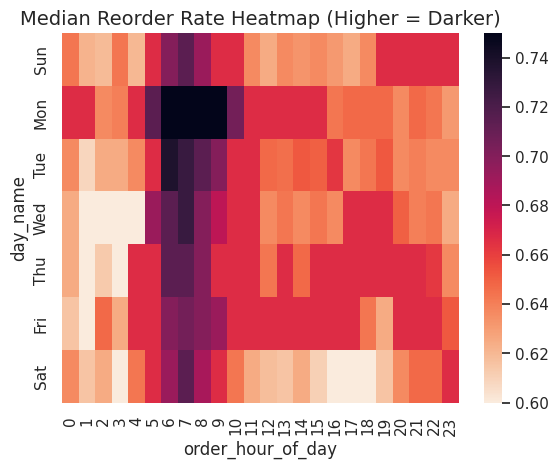

In [7]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="median_reorder_rate"
 )

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Median Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

<Axes: xlabel='order_hour_of_day', ylabel='median_reorder_rate'>

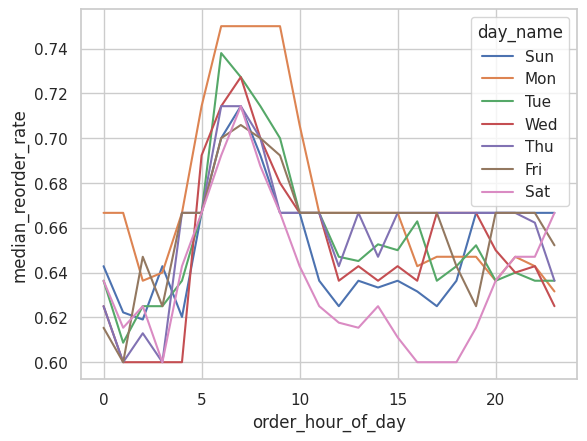

In [8]:
sns.lineplot(
    data=customer_kpi,
    x="order_hour_of_day",
    y="median_reorder_rate",
    hue="day_name"
    )

<Axes: xlabel='day_name', ylabel='reorder_rate'>

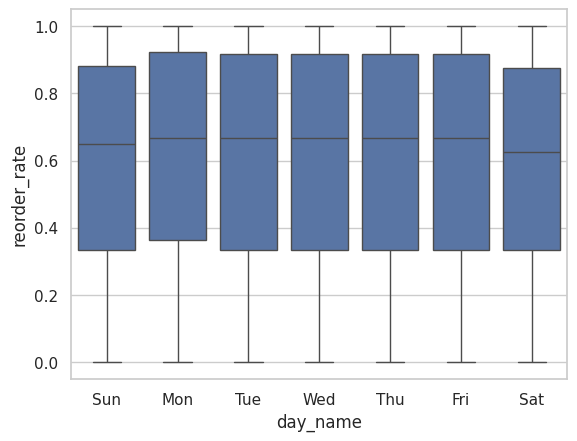

In [9]:
sns.boxplot(
    data=order_level,
    x="day_name",
    y="reorder_rate"
    )

## Segmentation Analysis

### 1 . Customer segmentation (RFM, cohort groups)

การแบ่งกลุ่มลูกค้า

RFM = Recency, Frequency, Monetary
- Recency → ลูกค้าซื้อล่าสุดเมื่อไหร่
- Frequency → ซื้อบ่อยแค่ไหน
- Monetary → ใช้เงินเยอะแค่ไหน
ใช้แบ่งลูกค้าเป็น: (VIP / Loyal, ลูกค้าใหม่, ลูกค้าที่กำลังจะหาย)

ส่วน Cohort group

คือการแบ่งตาม “ช่วงเวลาเริ่มใช้งาน”
เช่น ลูกค้าที่สมัครเดือนเดียวกัน

### -Rate Of Number of Purchase each Product Name

In [10]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("user_id")
    .agg(
        recency=("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("total_price", "median"),
    )
    .reset_index()
)

rfm["recency_score"] = pd.qcut(
    rfm["recency"].rank(method="first", ascending=False),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)

rfm["rfm_score"] = (
    rfm["recency_score"].astype(int)
    + rfm["frequency_score"].astype(int)
    + rfm["monetary_score"].astype(int)
)
rfm["segment"] = pd.cut(
    rfm["rfm_score"],
    bins=[0, 5, 8, 12],
    labels=["At Risk", "Regular", "Loyal"],
    include_lowest=True,
)

rfm.head()

,user_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment
0,1,1,10,1.0000,1,3,1,5,At Risk
1,2,1,14,1.0000,1,3,1,5,At Risk
2,3,1,12,1.0000,1,3,1,5,At Risk
3,4,1,5,1.0000,1,1,1,3,At Risk
4,5,1,4,1.0000,1,1,1,3,At Risk


### 2. Product preferences by customer segment
Use the transaction-level dataset joined with the RFM segment labels, because product fields do not exist in the aggregated `rfm` table.

ลูกค้าแต่ละกลุ่มชอบสินค้าอะไร
ตัวอย่าง:

- VIP → ชอบสินค้าแพง
- ลูกค้าใหม่ → ชอบของลดราคา`

💡 ใช้ทำ:
- Recommendation
- Marketing targeting

### - Rate 

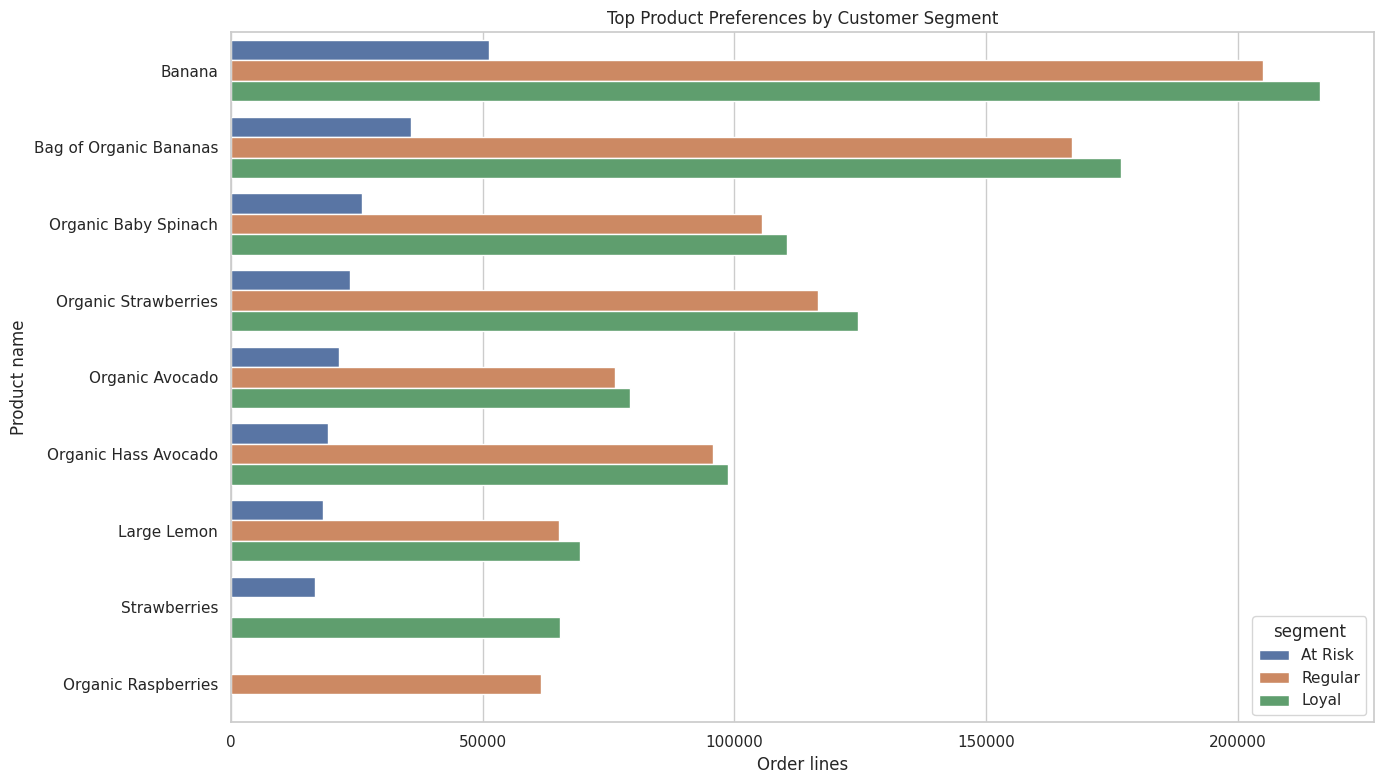

,segment,product_name,order_lines
0,At Risk,Banana,51216
1,At Risk,Bag of Organic Bananas,35675
2,At Risk,Organic Baby Spinach,25953
3,At Risk,Organic Strawberries,23552
4,At Risk,Organic Avocado,21488
5,At Risk,Organic Hass Avocado,19163
6,At Risk,Large Lemon,18227
7,At Risk,Strawberries,16588
8,Regular,Banana,205076
9,Regular,Bag of Organic Bananas,166981


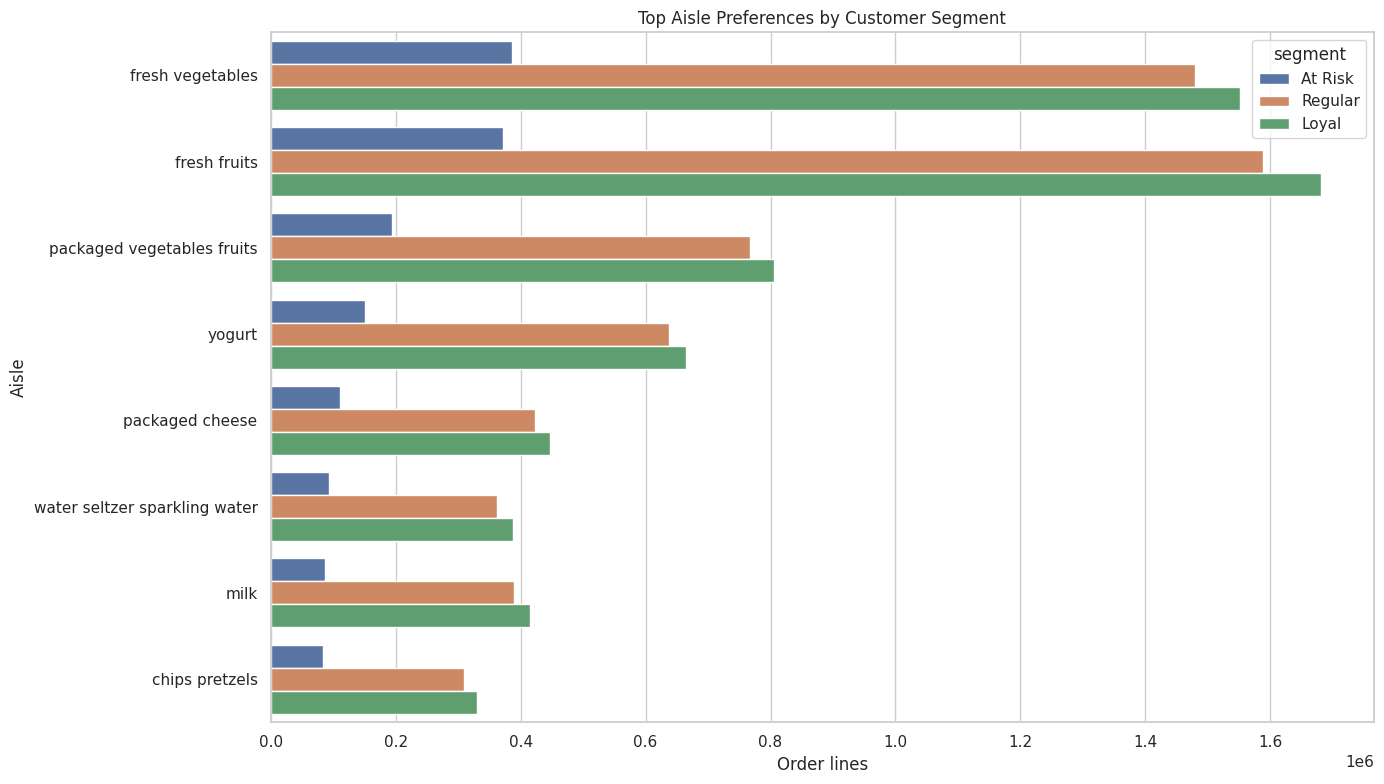

,segment,aisle,order_lines
0,At Risk,fresh vegetables,385572
1,At Risk,fresh fruits,371351
2,At Risk,packaged vegetables fruits,193286
3,At Risk,yogurt,150578
4,At Risk,packaged cheese,110285
5,At Risk,water seltzer sparkling water,92853
6,At Risk,milk,86113
7,At Risk,chips pretzels,83017
8,Regular,fresh fruits,1588953
9,Regular,fresh vegetables,1480183


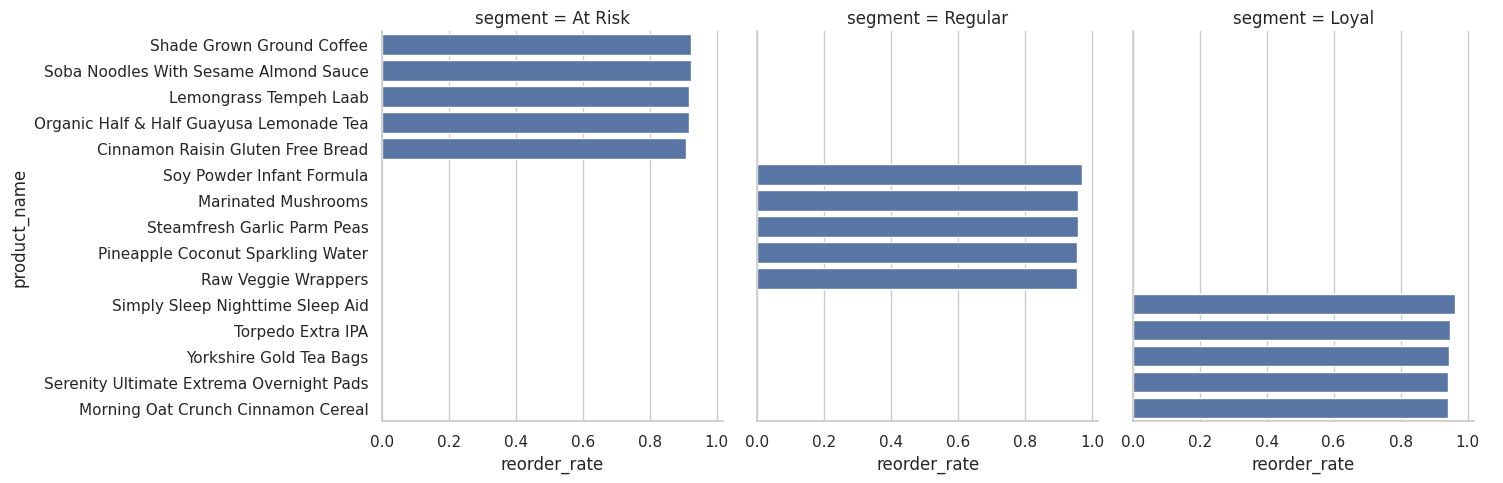

,segment,product_name,order_lines,reorder_rate
36092,At Risk,Shade Grown Ground Coffee,13,0.9231
37300,At Risk,Soba Noodles With Sesame Almond Sauce,13,0.9231
20651,At Risk,Lemongrass Tempeh Laab,12,0.9167
27239,At Risk,Organic Half & Half Guayusa Lemonade Tea,12,0.9167
8084,At Risk,Cinnamon Raisin Gluten Free Bread,11,0.9091
85693,Regular,Soy Powder Infant Formula,33,0.9697
68813,Regular,Marinated Mushrooms,23,0.9565
86695,Regular,Steamfresh Garlic Parm Peas,23,0.9565
78975,Regular,Pineapple Coconut Sparkling Water,45,0.9556
81437,Regular,Raw Veggie Wrappers,67,0.9552


In [11]:
segment_txn = df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

# Ensure aisle exists for aisle-level preference analysis.
if "aisle" not in segment_txn.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "aisle"]]
    segment_txn = segment_txn.merge(product_dim, on="product_id", how="left")

segment_product_pref = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.groupby(["segment", "product_name"])
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_by_segment = (
    top_reordered_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment")
    .head(5)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

display(top_products_by_segment)



plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

display(top_aisle_by_segment)


sns.catplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    col="segment",
    kind="bar",
    height=5,
    aspect=1
)
plt.show()

display(top_reordered_by_segment)

### 3. Retention / Churn analysis

Retention = ลูกค้ายัง active และกลับมาซื้อซ้ำในช่วงเวลาถัดไป
Churn = ลูกค้าไม่กลับมาซื้อภายในหน้าต่างเวลาที่กำหนด (inactivity threshold)

Framework ที่แนะนำ (ใช้ order_date):
1. สร้างเดือนของคำสั่งซื้อ: order_month
2. หา first_month ต่อ user เป็น cohort month
3. นับจำนวน user ที่ active ในแต่ละ month_index (0, 1, 2, ...)
4. คำนวณ retention_rate = active_users / cohort_size
5. กำหนด churn แบบธุรกิจ: เช่น ไม่สั่งซื้อเกิน 30 วัน = churn

หมายเหตุ: ใน Instacart ช่วงเวลาข้อมูลค่อนข้างสั้น การตั้ง threshold 30 วันมักเข้าใจง่ายและตีความได้ดี

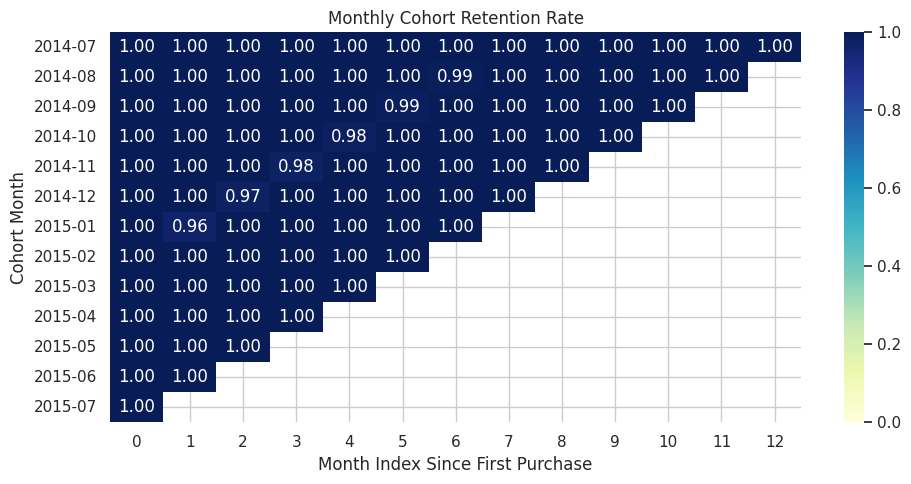

,cohort_month,month_index,active_users,cohort_size,retention_rate
0,2014-07,0,16749,16749,1.0000
1,2014-07,1,16749,16749,1.0000
2,2014-07,2,16749,16749,1.0000
3,2014-07,3,16749,16749,1.0000
4,2014-07,4,16749,16749,1.0000
5,2014-07,5,16749,16749,1.0000
6,2014-07,6,16749,16749,1.0000
7,2014-07,7,16706,16749,0.9974
8,2014-07,8,16749,16749,1.0000
9,2014-07,9,16749,16749,1.0000


,segment,customers,churn_30d_rate,median_days_since_last_order
0,At Risk,53526,0.0000,1.0000
1,Regular,75725,0.0000,1.0000
2,Loyal,76958,0.0000,1.0000


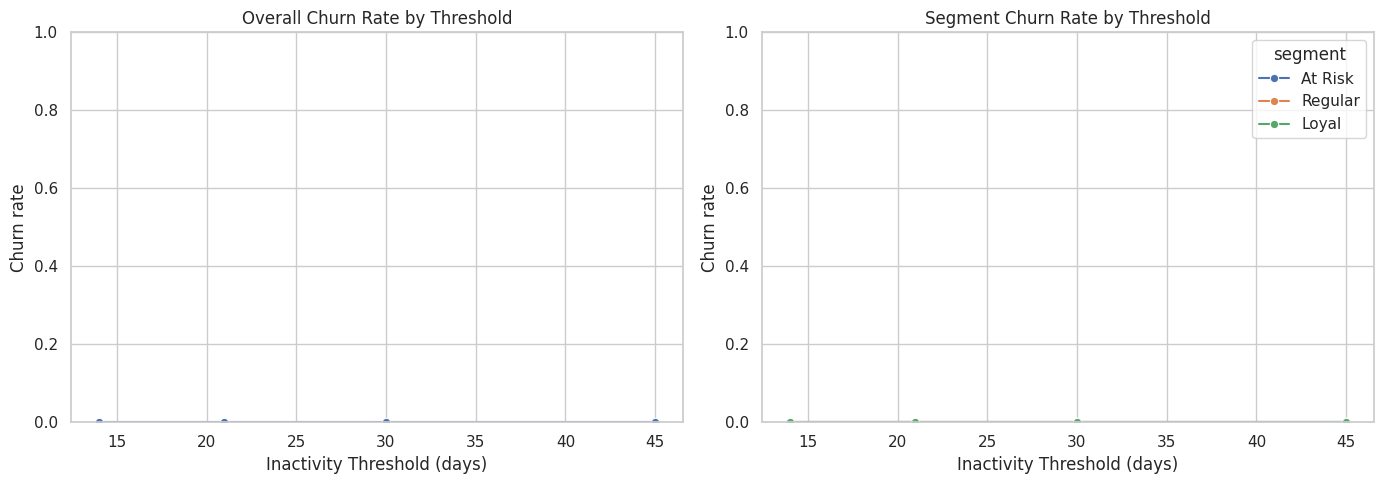

,threshold_days,churn_rate
0,14,0.0000
1,21,0.0000
2,30,0.0000
3,45,0.0000


,segment,churn_rate,threshold_days
0,At Risk,0.0000,14
3,At Risk,0.0000,21
6,At Risk,0.0000,30
9,At Risk,0.0000,45
1,Regular,0.0000,14
4,Regular,0.0000,21
7,Regular,0.0000,30
10,Regular,0.0000,45
2,Loyal,0.0000,14
5,Loyal,0.0000,21


In [12]:
# --- Retention (Monthly Cohort) + Churn (Inactivity) using order_date ---
orders_user = (
    df[["user_id", "order_id", "order_date"]]
    .drop_duplicates()
    .copy()
)

orders_user["order_month"] = orders_user["order_date"].dt.to_period("M")
first_month = orders_user.groupby("user_id")["order_month"].min().rename("cohort_month")
orders_user = orders_user.merge(first_month, on="user_id", how="left")

orders_user["month_index"] = (
    orders_user["order_month"].astype(int) - orders_user["cohort_month"].astype(int)
)

cohort_active = (
    orders_user.groupby(["cohort_month", "month_index"], observed=False)["user_id"]
    .nunique()
    .rename("active_users")
    .reset_index()
)
cohort_size = (
    orders_user.groupby("cohort_month", observed=False)["user_id"]
    .nunique()
    .rename("cohort_size")
    .reset_index()
)
cohort_retention = cohort_active.merge(cohort_size, on="cohort_month", how="left")
cohort_retention["retention_rate"] = cohort_retention["active_users"] / cohort_retention["cohort_size"]

retention_pivot = cohort_retention.pivot(
    index="cohort_month",
    columns="month_index",
    values="retention_rate",
)

plt.figure(figsize=(10, 5))
sns.heatmap(retention_pivot, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Monthly Cohort Retention Rate")
plt.xlabel("Month Index Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

display(cohort_retention.sort_values(["cohort_month", "month_index"]).head(20))

# Churn base table from last order date
snapshot_date = orders_user["order_date"].max() + pd.Timedelta(days=1)
last_order = orders_user.groupby("user_id")["order_date"].max().rename("last_order_date")
churn_df = last_order.to_frame().reset_index()
churn_df["days_since_last_order"] = (snapshot_date - churn_df["last_order_date"]).dt.days

# Churn at 30 days (kept for simple baseline report)
churn_df["is_churn_30d"] = churn_df["days_since_last_order"] > 30
churn_by_segment = (
    churn_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby("segment", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        churn_30d_rate=("is_churn_30d", "mean"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
display(churn_by_segment)

# Compare multiple churn thresholds
churn_thresholds = [14, 21, 30, 45]
churn_eval = churn_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

for t in churn_thresholds:
    churn_eval[f"is_churn_{t}d"] = churn_eval["days_since_last_order"] > t

overall_churn_curve = pd.DataFrame(
    {
        "threshold_days": churn_thresholds,
        "churn_rate": [
            churn_eval[f"is_churn_{t}d"].mean()
            for t in churn_thresholds
        ],
    }
)

segment_churn_curve = pd.concat(
    [
        churn_eval.groupby("segment", observed=False)[f"is_churn_{t}d"]
        .mean()
        .rename("churn_rate")
        .reset_index()
        .assign(threshold_days=t)
        for t in churn_thresholds
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=overall_churn_curve,
    x="threshold_days",
    y="churn_rate",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Overall Churn Rate by Threshold")
axes[0].set_xlabel("Inactivity Threshold (days)")
axes[0].set_ylabel("Churn rate")
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=segment_churn_curve,
    x="threshold_days",
    y="churn_rate",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Segment Churn Rate by Threshold")
axes[1].set_xlabel("Inactivity Threshold (days)")
axes[1].set_ylabel("Churn rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(overall_churn_curve)
display(segment_churn_curve.sort_values(["segment", "threshold_days"]))

### 4. Basket value or repeat rate by product category

Category summary (department) - top 12 by order lines:


,department,order_lines,unique_orders,unique_users,repeat_rate,avg_line_value,median_line_value,avg_category_basket_value,median_category_basket_value,p90_category_basket_value
0,produce,9479291,2409320,193237,0.6499,1.0000,1.0000,3.9344,3.0000,8.0000
1,dairy eggs,5414016,2177338,190565,0.6700,1.0000,1.0000,2.4865,2.0000,5.0000
2,snacks,2887550,1391447,174219,0.5742,1.0000,1.0000,2.0752,1.0000,4.0000
3,beverages,2690129,1457351,172795,0.6535,1.0000,1.0000,1.8459,1.0000,3.0000
4,frozen,2236432,1181018,163233,0.5419,1.0000,1.0000,1.8936,1.0000,4.0000
5,pantry,1875577,1117892,172755,0.3467,1.0000,1.0000,1.6778,1.0000,3.0000
6,bakery,1176787,881556,140612,0.6281,1.0000,1.0000,1.3349,1.0000,2.0000
7,canned goods,1068058,681305,133733,0.4574,1.0000,1.0000,1.5677,1.0000,3.0000
8,deli,1051249,770300,133865,0.6077,1.0000,1.0000,1.3647,1.0000,2.0000
9,dry goods pasta,866627,597862,124820,0.4611,1.0000,1.0000,1.4495,1.0000,2.0000


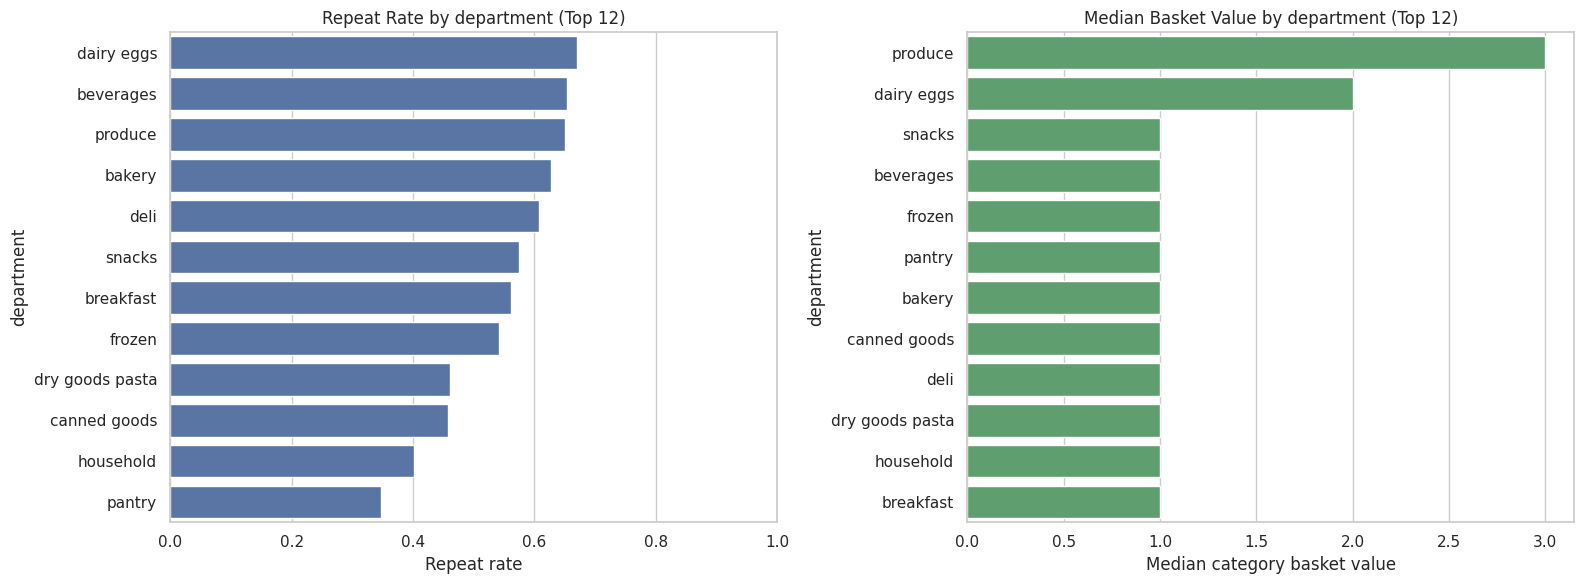

,department,order_lines,repeat_rate,avg_line_value,median_line_value,avg_category_basket_value,median_category_basket_value,p90_category_basket_value
count,21,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000
unique,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,produce,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,"1,544,499.4762",0.5211,1.0000,1.0000,1.6891,1.1429,2.9524
std,NaN,"2,231,519.2502",0.1098,0.0000,0.0000,0.6515,0.4781,1.5961
min,NaN,"34,573.0000",0.3211,1.0000,1.0000,1.0228,1.0000,1.0000
25%,NaN,"269,253.0000",0.4080,1.0000,1.0000,1.3349,1.0000,2.0000
50%,NaN,"738,666.0000",0.5677,1.0000,1.0000,1.5677,1.0000,3.0000
75%,NaN,"1,875,577.0000",0.6013,1.0000,1.0000,1.8459,1.0000,3.0000


In [15]:
# --- Basket value / Repeat rate by product category ---
CATEGORY_COL = "department"  # switch to "aisle" for finer granularity
TOP_N_CATEGORY = 12

category_df = df.copy()

# Ensure category column exists.
if CATEGORY_COL not in category_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", CATEGORY_COL]]
    category_df = category_df.merge(product_dim, on="product_id", how="left")

category_df[CATEGORY_COL] = category_df[CATEGORY_COL].fillna("Unknown")

# 1) Line-level metrics: repeat behavior + value per line by category
category_line_metrics = (
    category_df.groupby(CATEGORY_COL, observed=False)
    .agg(
        order_lines=("product_id", "count"),
        unique_orders=("order_id", "nunique"),
        unique_users=("user_id", "nunique"),
        repeat_rate=("reordered", "mean"),
        avg_line_value=("total_price", "mean"),
        median_line_value=("total_price", "median"),
    )
    .reset_index()
    .sort_values(["order_lines", CATEGORY_COL], ascending=[False, True])
)

# 2) Order-category basket metrics: spend per order within each category
order_category_value = (
    category_df.groupby(["order_id", CATEGORY_COL], observed=False)
    .agg(category_basket_value=("total_price", "sum"))
    .reset_index()
)

category_basket_metrics = (
    order_category_value.groupby(CATEGORY_COL, observed=False)
    .agg(
        avg_category_basket_value=("category_basket_value", "mean"),
        median_category_basket_value=("category_basket_value", "median"),
        p90_category_basket_value=("category_basket_value", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

category_summary = (
    category_line_metrics.merge(category_basket_metrics, on=CATEGORY_COL, how="left")
    .sort_values(["order_lines", CATEGORY_COL], ascending=[False, True])
    .reset_index(drop=True)
)

top_categories = category_summary.head(TOP_N_CATEGORY).copy()

print(f"Category summary ({CATEGORY_COL}) - top {TOP_N_CATEGORY} by order lines:")
display(top_categories)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_categories.sort_values("repeat_rate", ascending=False),
    x="repeat_rate",
    y=CATEGORY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Repeat Rate by {CATEGORY_COL} (Top {TOP_N_CATEGORY})")
axes[0].set_xlabel("Repeat rate")
axes[0].set_ylabel(CATEGORY_COL)
axes[0].set_xlim(0, 1)

sns.barplot(
    data=top_categories.sort_values("median_category_basket_value", ascending=False),
    x="median_category_basket_value",
    y=CATEGORY_COL,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title(f"Median Basket Value by {CATEGORY_COL} (Top {TOP_N_CATEGORY})")
axes[1].set_xlabel("Median category basket value")
axes[1].set_ylabel(CATEGORY_COL)

plt.tight_layout()
plt.show()

display(
    category_summary[[
        CATEGORY_COL,
        "order_lines",
        "repeat_rate",
        "avg_line_value",
        "median_line_value",
        "avg_category_basket_value",
        "median_category_basket_value",
        "p90_category_basket_value",
    ]].describe(include="all")
)

### 5. Customer lifetime value (CLV) trends

### 6. User & Product Trend Deep Dive

This section adds:
- User trend (active users, orders per active user, reorder rate) by week/month
- Product trend (top N products/departments) with order lines and share of total
- Histogram supplements for behavior and growth distributions

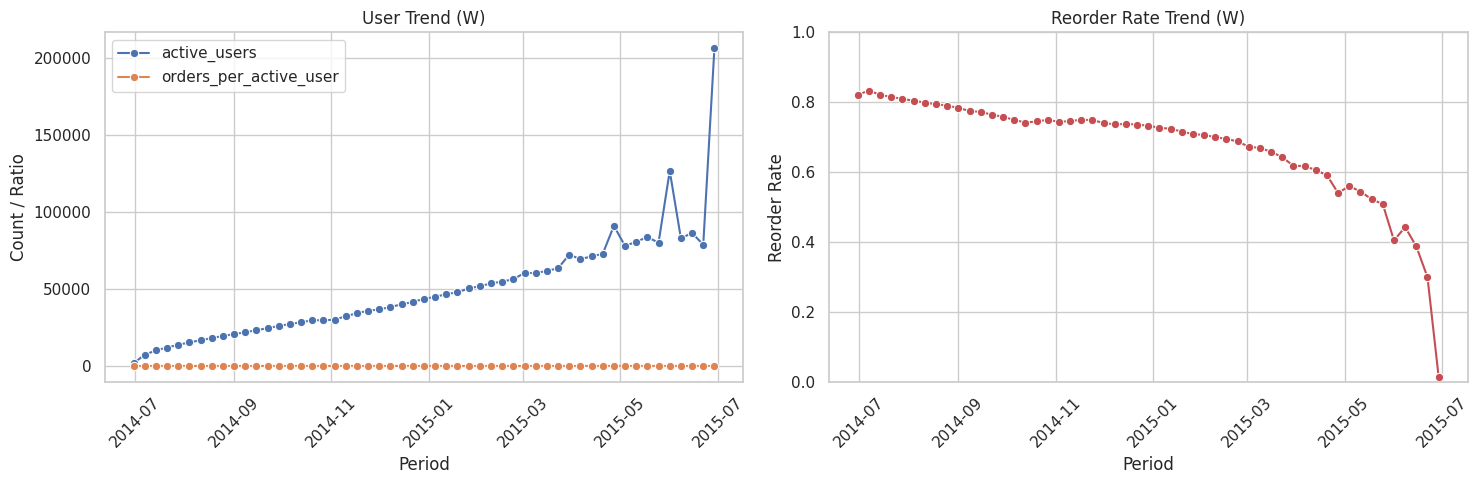

,period,active_users,orders,order_lines,reorder_rate,orders_per_active_user
0,2014-06-30,1751,2048,20541,0.8219,1.1696
1,2014-07-07,7266,9902,116219,0.8329,1.3628
2,2014-07-14,10062,13618,159468,0.8213,1.3534
3,2014-07-21,11942,16140,186121,0.8149,1.3515
4,2014-07-28,13713,18547,211681,0.8096,1.3525
5,2014-08-04,15257,20418,233989,0.8041,1.3383
6,2014-08-11,16691,22327,254191,0.7992,1.3377
7,2014-08-18,18060,24169,275798,0.7941,1.3383
8,2014-08-25,19439,25891,295816,0.7901,1.3319
9,2014-09-01,20658,27422,309658,0.7840,1.3274


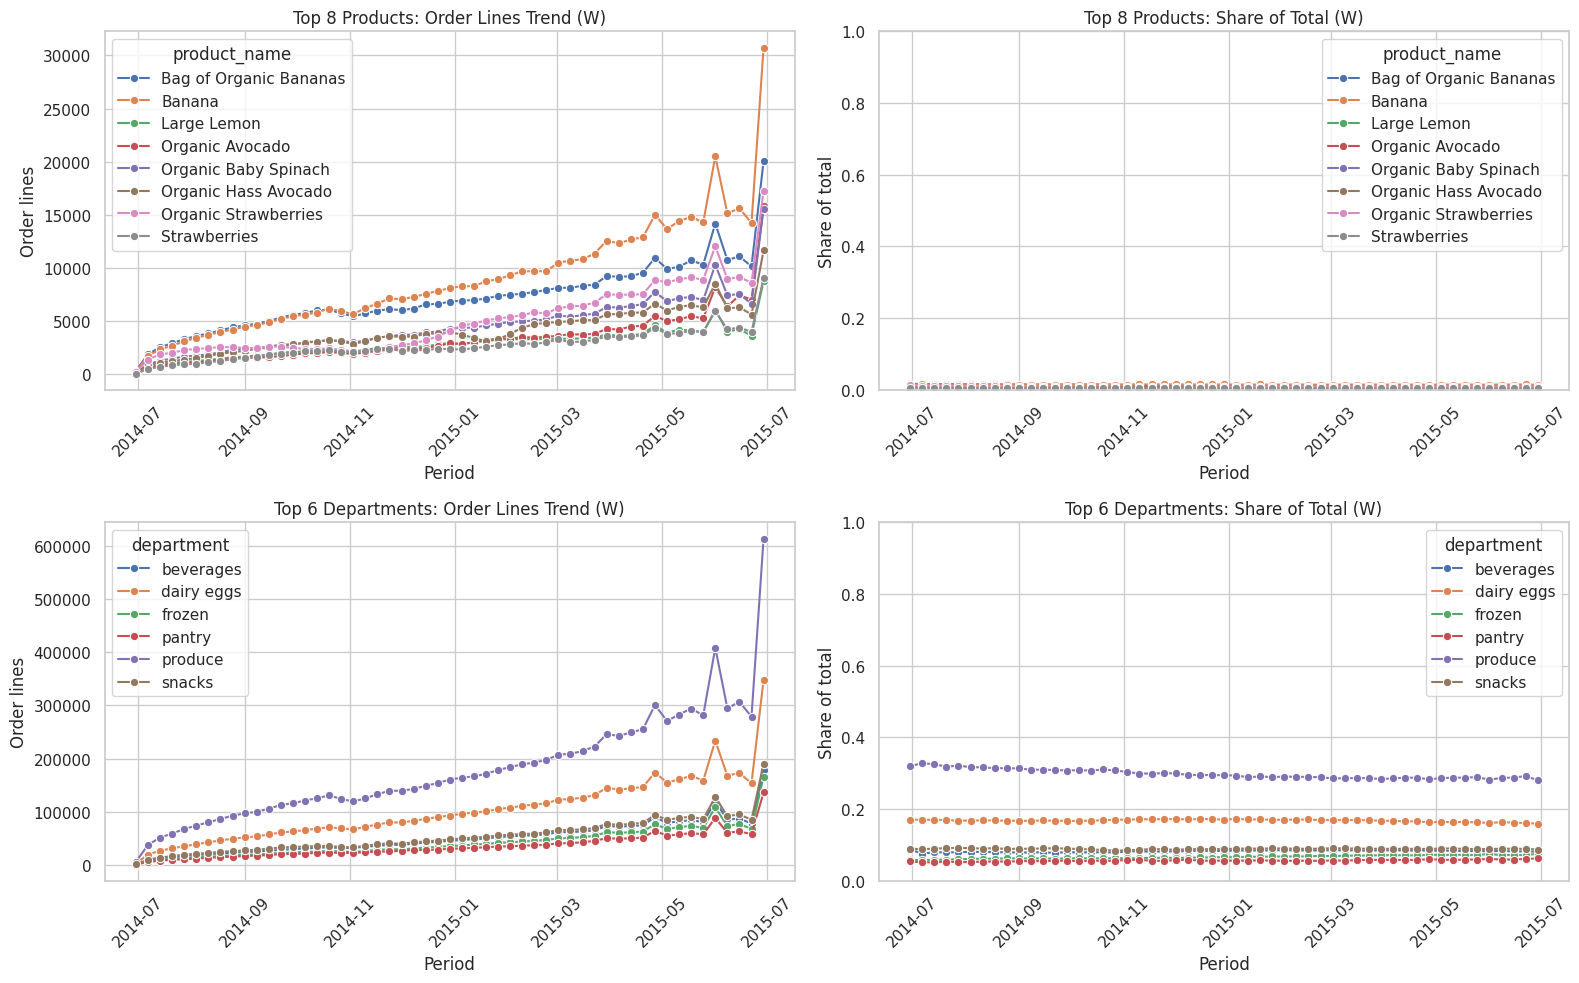

,period,product_name,order_lines,total_lines_period,share_of_total
0,2014-06-30,Bag of Organic Bananas,347,20541,0.0169
8,2014-07-07,Bag of Organic Bananas,1901,116219,0.0164
16,2014-07-14,Bag of Organic Bananas,2554,159468,0.0160
24,2014-07-21,Bag of Organic Bananas,2936,186121,0.0158
32,2014-07-28,Bag of Organic Bananas,3317,211681,0.0157
40,2014-08-04,Bag of Organic Bananas,3609,233989,0.0154
48,2014-08-11,Bag of Organic Bananas,3860,254191,0.0152
56,2014-08-18,Bag of Organic Bananas,4138,275798,0.0150
64,2014-08-25,Bag of Organic Bananas,4430,295816,0.0150
72,2014-09-01,Bag of Organic Bananas,4602,309658,0.0149


,period,department,order_lines,total_lines_period,share_of_total
0,2014-06-30,beverages,1792,20541,0.0872
6,2014-07-07,beverages,8860,116219,0.0762
12,2014-07-14,beverages,12687,159468,0.0796
18,2014-07-21,beverages,14773,186121,0.0794
24,2014-07-28,beverages,16879,211681,0.0797
30,2014-08-04,beverages,18859,233989,0.0806
36,2014-08-11,beverages,20498,254191,0.0806
42,2014-08-18,beverages,21986,275798,0.0797
48,2014-08-25,beverages,23581,295816,0.0797
54,2014-09-01,beverages,24351,309658,0.0786


In [13]:
# --- User trend + Product trend (Top N + Share) ---
TREND_FREQ = "W"  # use "M" for monthly
TOP_N_PRODUCTS = 8
TOP_N_DEPARTMENTS = 6

trend_df = df.copy()
trend_df["period"] = trend_df["order_date"].dt.to_period(TREND_FREQ).dt.to_timestamp()

# User trend metrics
user_trend = (
    trend_df.groupby("period", observed=False)
    .agg(
        active_users=("user_id", "nunique"),
        orders=("order_id", "nunique"),
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)
user_trend["orders_per_active_user"] = user_trend["orders"] / user_trend["active_users"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=user_trend, x="period", y="active_users", marker="o", ax=axes[0], label="active_users")
sns.lineplot(data=user_trend, x="period", y="orders_per_active_user", marker="o", ax=axes[0], label="orders_per_active_user")
axes[0].set_title(f"User Trend ({TREND_FREQ})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Count / Ratio")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=user_trend, x="period", y="reorder_rate", marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title(f"Reorder Rate Trend ({TREND_FREQ})")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(user_trend)

# Product trend prep: ensure department exists
if "department" not in trend_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "department"]]
    trend_df = trend_df.merge(product_dim, on="product_id", how="left")

period_total_lines = (
    trend_df.groupby("period", observed=False)
    .size()
    .rename("total_lines_period")
    .reset_index()
)

# Top N products by overall order lines
top_products = (
    trend_df["product_name"].value_counts().head(TOP_N_PRODUCTS).index.tolist()
)
product_period = (
    trend_df[trend_df["product_name"].isin(top_products)]
    .groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
product_period["share_of_total"] = product_period["order_lines"] / product_period["total_lines_period"]

# Top N departments by overall order lines
top_departments = (
    trend_df["department"].dropna().value_counts().head(TOP_N_DEPARTMENTS).index.tolist()
)
dept_period = (
    trend_df[trend_df["department"].isin(top_departments)]
    .groupby(["period", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
dept_period["share_of_total"] = dept_period["order_lines"] / dept_period["total_lines_period"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(
    data=product_period,
    x="period",
    y="order_lines",
    hue="product_name",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Top {TOP_N_PRODUCTS} Products: Order Lines Trend ({TREND_FREQ})")
axes[0, 0].set_xlabel("Period")
axes[0, 0].set_ylabel("Order lines")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=product_period,
    x="period",
    y="share_of_total",
    hue="product_name",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"Top {TOP_N_PRODUCTS} Products: Share of Total ({TREND_FREQ})")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Share of total")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="order_lines",
    hue="department",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Order Lines Trend ({TREND_FREQ})")
axes[1, 0].set_xlabel("Period")
axes[1, 0].set_ylabel("Order lines")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="share_of_total",
    hue="department",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Share of Total ({TREND_FREQ})")
axes[1, 1].set_xlabel("Period")
axes[1, 1].set_ylabel("Share of total")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(product_period.sort_values(["product_name", "period"]).head(30))
display(dept_period.sort_values(["department", "period"]).head(30))

### 7. Histogram Supplements

Use histograms to understand distribution shape (not time trend):
- days_since_prior_order
- order frequency per user
- product growth rate between periods

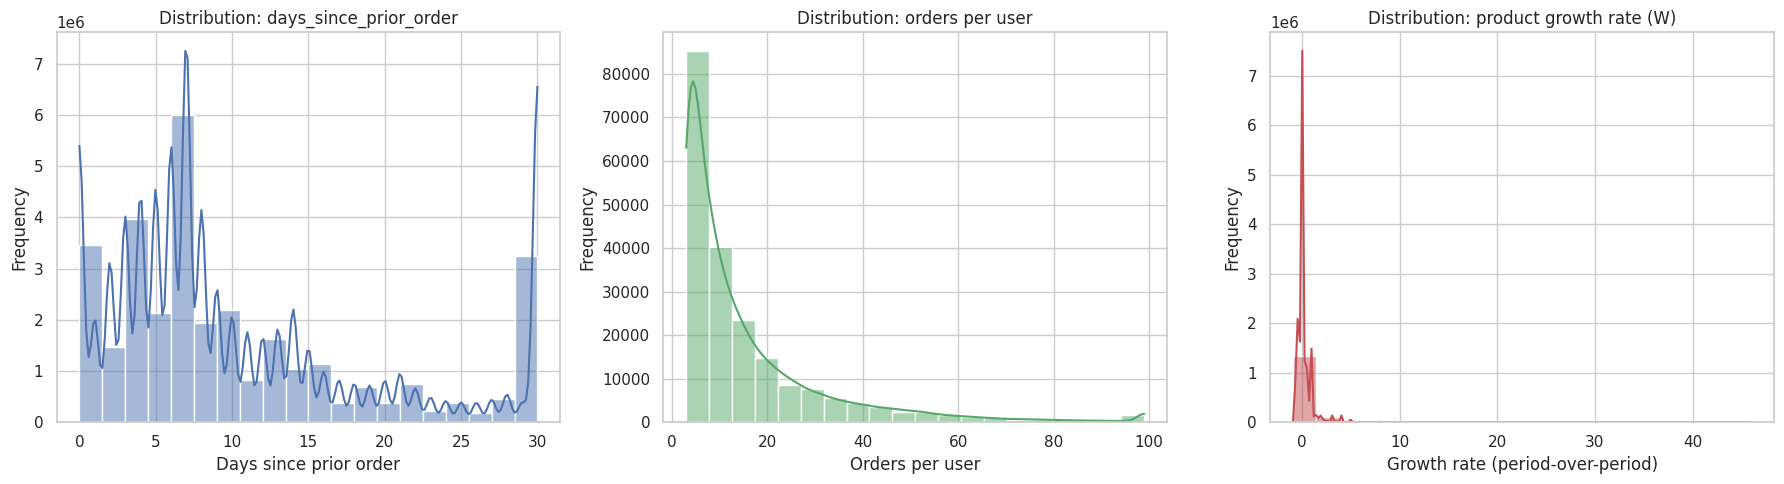

,orders_per_user
count,"206,209.0000"
mean,15.5904
std,16.6548
min,3.0000
25%,5.0000
50%,9.0000
75%,19.0000
max,99.0000


,product_growth_rate
count,"1,458,728.0000"
mean,0.2695
std,0.9383
min,-0.9375
25%,-0.2000
50%,0.0000
75%,0.5000
max,46.0000


In [14]:
# --- Histogram supplements ---

# 1) Distribution of days_since_prior_order
days_dist = df["days_since_prior_order"].dropna()

# 2) Distribution of order frequency per user
user_order_freq = (
    df.groupby("user_id", observed=False)["order_id"]
    .nunique()
    .rename("orders_per_user")
)

# 3) Distribution of product growth rate between periods
growth_base = (
    trend_df.groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
growth_base = growth_base.sort_values(["product_name", "period"])
growth_base["product_growth_rate"] = growth_base.groupby("product_name", observed=False)["order_lines"].pct_change()

# Keep finite growth values for histogram
growth_values = growth_base["product_growth_rate"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(days_dist, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution: days_since_prior_order")
axes[0].set_xlabel("Days since prior order")
axes[0].set_ylabel("Frequency")

sns.histplot(user_order_freq, bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution: orders per user")
axes[1].set_xlabel("Orders per user")
axes[1].set_ylabel("Frequency")

sns.histplot(growth_values, bins=20, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Distribution: product growth rate ({TREND_FREQ})")
axes[2].set_xlabel("Growth rate (period-over-period)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

display(user_order_freq.describe().to_frame(name="orders_per_user"))
display(growth_values.describe().to_frame(name="product_growth_rate"))